<a href="https://colab.research.google.com/github/hwasun-zip/festforecast/blob/main/notebooks/01_reimplementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
# FestForecast 재구현 — 지역 축제 방문객과 날씨
#문체부 연도별 축제 데이터(2022–2025) × 기상청 ASOS 일자료로 원 프로젝트 파이프라인을 재구현한다.
#각 연도 파일의 방문객은 전년도 실적이므로, 연도 간 축제명 정규화 조인으로 (기간, 방문객) 쌍을 복원했다.

In [22]:
import pandas as pd

files = {
    2022: "/content/2022년 지역축제 개최 계획(취합).xlsx",
    2023: "/content/2023년 지역축제 개최 계획(취합).xlsx",
    2024: "/content/2024년 지역축제 개최계획(홈페이지 게시)0930.xlsx",
    2025: "/content/2025년 지역축제 개최계획 현황(0321).xlsx",
}

def read_headered(path):
    xls = pd.ExcelFile(path)
    for sh in xls.sheet_names:
        raw = pd.read_excel(path, sheet_name=sh, header=None, dtype=str)
        if len(raw) < 50:
            continue
        for i in range(min(10, len(raw))):
            row = raw.iloc[i]
            hits = row[row.str.contains("축제명", na=False)]
            if hits.empty:
                continue
            name_col = hits.index[0]
            top = raw.iloc[i].ffill()
            sub = raw.iloc[i + 1].fillna("") if i + 1 < len(raw) else raw.iloc[i] * 0
            cols = (top.fillna("") + " " + sub).str.replace("\n", " ").str.strip()
            body = raw.iloc[i + 1:].reset_index(drop=True)
            mask = body[name_col].notna() & ~body[name_col].astype(str).str.contains("축제명")
            if not mask.any():
                continue
            body = body.iloc[mask.idxmax():].reset_index(drop=True)
            return sh, cols, body
    raise ValueError(f"목록 시트를 못 찾음 / 시트들: {xls.sheet_names}")

def find_col(cols, *keywords, exclude=()):
    for i, c in enumerate(cols):
        s = str(c).replace(" ", "")
        if all(k in s for k in keywords) and not any(e in s for e in exclude):
            return i
    return None

for year, path in files.items():
    try:
        sh, cols, body = read_headered(path)
        idx = {
            "광역": find_col(cols, "광역"),
            "기초": find_col(cols, "기초"),
            "축제명": find_col(cols, "축제명", exclude=("유형",)),
            "개최기간": find_col(cols, "개최기간"),
            "방문객": find_col(cols, "방문객", "합계") or find_col(cols, "방문객", "전체"),
        }
        print(f"===== {year} | 시트: '{sh}' | 데이터 {len(body)}행 | 위치: {idx}")
        take = {k: v for k, v in idx.items() if v is not None}
        sample = body.iloc[:3, list(take.values())]
        sample.columns = list(take.keys())
        print(sample.to_string(index=False), "\n")
    except Exception as e:
        print(f"===== {year} | ⚠️ 실패: {type(e).__name__}: {e}\n")

===== 2022 | 시트: '세부현황' | 데이터 944행 | 위치: {'광역': 2, '기초': 3, '축제명': 4, '개최기간': 6, '방문객': None}
광역  기초           축제명           개최기간
서울  본청  2022 서울빛초롱축제  11.4.~20.(예정)
서울 강동구 제27회 강동선사문화축제 22. 10. 8.~10.
서울 강서구          허준축제    10.6.~10.9. 

===== 2023 | 시트: '세부현황' | 데이터 1129행 | 위치: {'광역': 2, '기초': 3, '축제명': 4, '개최기간': 6, '방문객': None}
광역 기초              축제명                                                                                 개최기간
서울  -         서울뮤직페스티벌                                                                          10.20~10.22
서울  - 차 없는 잠수교 뚜벅뚜벅 축제 -상반기:4.30.~7.2.  \n매주 일요일(10회)\n-하반기:9.3.~11.12. 매주 일요일(10회)\n * 10. 1.(일) : 추석연휴 제외
서울  -      2023 한강페스티벌              봄(5.12.~5.14.).\n여름(7.28.~8.13.),\n가을(10.14.~10.21.),\n겨울(12.1.~12.25.) 

===== 2024 | 시트: '세부현황' | 데이터 1170행 | 위치: {'광역': 2, '기초': 3, '축제명': 4, '개최기간': 6, '방문객': 14}
광역 기초      축제명      개최기간   방문객
서울  - 서울드럼페스티벌 5.25~5.26 12500
서울  - 서울뮤직페스티벌 9.27~9.29 12274
서울  -   서울국악축제      9월 중 17442 

===== 2025 |

/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


In [23]:
for year in (2022, 2023):
    sh, cols, body = read_headered(files[year])
    print(f"===== {year} — '방문' 또는 '합계'가 들어간 컬럼들:")
    for i, c in enumerate(cols):
        s = str(c).replace(" ", "")
        if "방문" in s or "합계" in s:
            print(f"  [{i}] {repr(c)}  | 데이터 예시: {body.iloc[0, i]}, {body.iloc[1, i]}, {body.iloc[2, i]}")

===== 2022 — '방문' 또는 '합계'가 들어간 컬럼들:
  [13] '예산(백만원) 합계'  | 데이터 예시: 700, 617, 395
  [14] '방문객수(前년) 내국인'  | 데이터 예시: 51433, 10000, 50,000명
  [15] '방문객수(前년) 외국인'  | 데이터 예시: nan, -, 1,500명
===== 2023 — '방문' 또는 '합계'가 들어간 컬럼들:
  [13] '예산(백만원) 합계'  | 데이터 예시: 1180, 1368, 954
  [14] '방문객수(前년) 내국인(명)'  | 데이터 예시: 10000, 520000, 77000
  [15] '방문객수(前년) 외국인(명)'  | 데이터 예시: 1000, 추산불가, 추산불가


In [24]:
import re
import numpy as np

def to_num(x):
    s = str(x).replace(",", "").replace("명", "").strip()
    return float(s) if re.fullmatch(r"\d+(\.\d+)?", s) else np.nan

def extract(year):
    sh, cols, body = read_headered(files[year])
    g = lambda *kw, **k: find_col(cols, *kw, **k)
    df = pd.DataFrame({
        "광역": body.iloc[:, g("광역")].str.strip(),
        "기초": body.iloc[:, g("기초")].str.strip(),
        "축제명": body.iloc[:, g("축제명", exclude=("유형",))].str.strip(),
    })
    i_dur = g("개최기간")
    df["기간"] = body.iloc[:, i_dur] if i_dur is not None else np.nan

    i_tot = g("방문객", "합계") or g("방문객", "전체")
    if i_tot is not None:
        df["방문객"] = body.iloc[:, i_tot].map(to_num)
    else:
        dom = body.iloc[:, g("방문객", "내국인")].map(to_num)
        fgn = body.iloc[:, g("방문객", "외국인")].map(to_num)
        df["방문객"] = dom.add(fgn, fill_value=0)   # 둘 다 결측이면 결측 유지
    df["파일연도"] = year
    return df

data = {y: extract(y) for y in files}

for y, df in data.items():
    ok = df["방문객"].notna().sum()
    print(f"{y}파일: {len(df)}행 | 방문객 숫자 확보: {ok}행 ({ok/len(df):.0%})")
print("\n2023파일 샘플 (방문객 = 2022년 실적):")
print(data[2023].dropna(subset=["방문객"]).head(5).to_string(index=False))

2022파일: 944행 | 방문객 숫자 확보: 474행 (50%)
2023파일: 1129행 | 방문객 숫자 확보: 883행 (78%)
2024파일: 1170행 | 방문객 숫자 확보: 1132행 (97%)
2025파일: 1214행 | 방문객 숫자 확보: 1078행 (89%)

2023파일 샘플 (방문객 = 2022년 실적):
광역  기초                          축제명                                                                                   기간      방문객  파일연도
서울   -                     서울뮤직페스티벌                                                                          10.20~10.22  11000.0  2023
서울   -             차 없는 잠수교 뚜벅뚜벅 축제 -상반기:4.30.~7.2.  \n매주 일요일(10회)\n-하반기:9.3.~11.12. 매주 일요일(10회)\n * 10. 1.(일) : 추석연휴 제외 520000.0  2023
서울   -                  2023 한강페스티벌              봄(5.12.~5.14.).\n여름(7.28.~8.13.),\n가을(10.14.~10.21.),\n겨울(12.1.~12.25.)  77000.0  2023
서울 용산구                제25회 서울드럼페스티벌                                                                        05.26.~05.27.  13839.0  2023
서울 송파구 2023 석촌호수의 가을과 겨울, 그리고 루미나리에                                                                    10.27.~12.31.(예정) 201000.0  2023


/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


In [25]:
def norm_name(s):
    s = str(s)
    s = re.sub(r"제?\s*\d+\s*회", "", s)          # '제25회', '25회' 제거
    s = re.sub(r"20\d{2}", "", s)                 # '2023' 같은 연도 제거
    s = re.sub(r"[^가-힣a-zA-Z0-9]", "", s)       # 공백·특수문자 제거
    return s

def with_key(df):
    d = df.copy()
    d["키"] = d["광역"].fillna("") + "|" + d["축제명"].map(norm_name)
    return d

fest_years = []
for y in [2022, 2023, 2024]:
    base = with_key(data[y])[["키", "광역", "기초", "축제명", "기간"]]
    vis = with_key(data[y + 1])[["키", "방문객"]].dropna(subset=["방문객"])

    # 같은 키가 양쪽에 여러 번 나오면 잘못 이어질 수 있으니 중복 키는 제외 (보수적 선택)
    base = base[~base["키"].duplicated(keep=False)]
    vis = vis[~vis["키"].duplicated(keep=False)]

    m = base.merge(vis, on="키", how="left")
    matched = m["방문객"].notna().sum()
    print(f"{y}년: 축제 {len(base)}개 중 이듬해 파일과 매칭 {matched}개 ({matched/len(base):.0%})")

    m = m.dropna(subset=["방문객"]).assign(연도=y)
    fest_years.append(m)

fest = pd.concat(fest_years, ignore_index=True)[["연도", "광역", "기초", "축제명", "기간", "방문객"]]
print(f"\n최종 데이터셋: {len(fest)}행 (연도-축제 단위)")
print(fest.sample(5, random_state=1).to_string(index=False))
fest.to_csv("festival_3years.csv", index=False)
print("\nfestival_3years.csv 저장 완료")

2022년: 축제 940개 중 이듬해 파일과 매칭 415개 (44%)
2023년: 축제 1125개 중 이듬해 파일과 매칭 657개 (58%)
2024년: 축제 1160개 중 이듬해 파일과 매칭 675개 (58%)

최종 데이터셋: 1747행 (연도-축제 단위)
  연도 광역   기초                       축제명            기간      방문객
2023 경남  고성군 2023 기월 안뜰 경관농업\n지구 봄꽃 축제          4월 중   5000.0
2024 전남  신안군                    섬 홍어축제          5월 중   2100.0
2022 인천  NaN               제6회 주섬주섬음악회           7월중   6000.0
2022 경기 의정부시              제4회 블랙뮤직페스티벌   8.27.~8.28.  15740.0
2023 울산    -             태화강 국가정원 가을축제 10.20.~10.22. 210078.0

festival_3years.csv 저장 완료


In [26]:
def nums(x):
    return [int(n) for n in re.findall(r"\d+", x)]

def parse_period(s, year):
    if pd.isna(s):
        return ("실패", None, None, None)
    t = str(s)
    if "\n" in t or t.count("~") > 1:
        return ("복수기간", None, None, None)          # 4계절 축제 등 → 제외
    t = re.sub(r"\(.*?\)", "", t).replace(" ", "")     # (예정) 같은 괄호 제거
    m = re.fullmatch(r"(\d{1,2})월중?", t)
    if m:
        return ("월단위", None, None, int(m.group(1)))  # 'M월 중' → 월평균 날씨로 매칭
    if "~" not in t:
        return ("실패", None, None, None)
    left, right = t.split("~", 1)
    L, R = nums(left), nums(right)
    if len(L) == 3 and 20 <= L[0] <= 26: L = L[1:]      # '22.10.8.' 앞의 연도 제거
    if len(R) == 3 and 20 <= R[0] <= 26: R = R[1:]
    if len(L) != 2:
        return ("실패", None, None, None)
    sm, sd = L
    if len(R) == 2:   em, ed = R
    elif len(R) == 1: em, ed = sm, R[0]                 # '11.4.~20.' → 같은 달
    else:
        return ("실패", None, None, None)
    try:
        start, end = pd.Timestamp(year, sm, sd), pd.Timestamp(year, em, ed)
    except ValueError:
        return ("실패", None, None, None)
    if end < start:
        return ("실패", None, None, None)               # 연말~연초 걸침 등은 제외
    return ("일단위", start, end, sm)

parsed = fest.apply(lambda r: parse_period(r["기간"], r["연도"]), axis=1, result_type="expand")
parsed.columns = ["파싱", "시작일", "종료일", "월"]
fest2 = pd.concat([fest, parsed], axis=1)

print(fest2["파싱"].value_counts().to_string(), "\n")
print("실패 사례 10개 (다음 개선 대상):")
print(fest2.loc[fest2["파싱"] == "실패", "기간"].dropna().sample(min(10, (fest2["파싱"]=="실패").sum()), random_state=1).to_string(index=False))

use = fest2[fest2["파싱"].isin(["일단위", "월단위"])].copy()
print(f"\n사용 가능 데이터: {len(use)}행 (일단위 {(use['파싱']=='일단위').sum()} + 월단위 {(use['파싱']=='월단위').sum()})")
use.to_csv("festival_parsed.csv", index=False)

파싱
일단위     698
월단위     623
실패      383
복수기간     43 

실패 사례 10개 (다음 개선 대상):
2023.12.31.~2024.1.1.
             9월~10월 중
           2023.12월 중
             10~11월 중
        2024.6월중(3일간)
            2024. 11.
     2022. 8.11.~8.14
              7월말~8월초
     2024.4.20.~4.21.
             9월~10월 중

사용 가능 데이터: 1321행 (일단위 698 + 월단위 623)


In [27]:
def parse_period(s, year):
    if pd.isna(s):
        return ("실패", None, None, None)
    t = str(s)
    if "\n" in t or t.count("~") > 1:
        return ("복수기간", None, None, None)
    t = re.sub(r"\(.*?\)", "", t).replace(" ", "")
    t = re.sub(r"20\d{2}[.년]?", "", t)                 # 4자리 연도 제거 (연도 컬럼이 따로 있음)

    m = re.fullmatch(r"(\d{1,2})월중?", t)
    if m:
        return ("월단위", None, None, int(m.group(1)))
    m = re.fullmatch(r"(\d{1,2})\.?", t)                # '2024. 11.' → '11.'
    if m and 1 <= int(m.group(1)) <= 12:
        return ("월단위", None, None, int(m.group(1)))
    m = re.fullmatch(r"(\d{1,2})월?~(\d{1,2})월중?", t)  # '9월~10월 중' → 시작 월 기준
    if m and 1 <= int(m.group(1)) <= 12:
        return ("월단위", None, None, int(m.group(1)))

    if "~" not in t:
        return ("실패", None, None, None)
    left, right = t.split("~", 1)
    L, R = nums(left), nums(right)
    if len(L) == 3 and 20 <= L[0] <= 26: L = L[1:]
    if len(R) == 3 and 20 <= R[0] <= 26: R = R[1:]
    if len(L) != 2:
        return ("실패", None, None, None)
    sm, sd = L
    if len(R) == 2:   em, ed = R
    elif len(R) == 1: em, ed = sm, R[0]
    else:
        return ("실패", None, None, None)
    try:
        start, end = pd.Timestamp(year, sm, sd), pd.Timestamp(year, em, ed)
    except ValueError:
        return ("실패", None, None, None)
    if end < start:
        return ("실패", None, None, None)
    return ("일단위", start, end, sm)

parsed = fest.apply(lambda r: parse_period(r["기간"], r["연도"]), axis=1, result_type="expand")
parsed.columns = ["파싱", "시작일", "종료일", "월"]
fest2 = pd.concat([fest, parsed], axis=1)
print(fest2["파싱"].value_counts().to_string())

use = fest2[fest2["파싱"].isin(["일단위", "월단위"])].copy()
print(f"\n사용 가능: {len(use)}행")
use.to_csv("festival_parsed.csv", index=False)

print("\n광역별 분포 (날씨 관측지점 선정용):")
print(use["광역"].value_counts().to_string())

파싱
월단위     757
일단위     721
실패      226
복수기간     43

사용 가능: 1478행

광역별 분포 (날씨 관측지점 선정용):
광역
경기    193
경남    184
전남    170
충남    138
전북    123
강원    123
경북    104
부산     79
제주     68
충북     64
대구     60
울산     50
서울     48
인천     31
광주     23
대전     15
세종      5


In [28]:
wpath = "/content/OBS_ASOS_DD_20260710182352.csv"

try:
    weather = pd.read_csv(wpath, encoding="cp949")
except UnicodeDecodeError:
    weather = pd.read_csv(wpath, encoding="utf-8")

print("컬럼:", list(weather.columns))
print("행수:", len(weather))
print("\n지점명 목록:", sorted(weather["지점명"].unique()) if "지점명" in weather.columns else "지점명 컬럼 없음")
print("\n샘플:")
print(weather.head(3).to_string(index=False))

컬럼: ['지점', '지점명', '일시', '평균기온(°C)', '일강수량(mm)', '평균 풍속(m/s)', '평균 상대습도(%)']
행수: 105384

지점명 목록: ['강릉', '강진군', '강화', '거제', '거창', '경주시', '고산', '고창', '고창군', '고흥', '광양시', '광주', '구미', '군산', '금산', '김해시', '남원', '남해', '대관령', '대구', '대전', '동두천', '동해', '목포', '문경', '밀양', '백령도', '보령', '보성군', '보은', '봉화', '부산', '부안', '부여', '북강릉', '북부산', '북창원', '북춘천', '산청', '상주', '서귀포', '서산', '서울', '서청주', '성산', '세종', '속초', '수원', '순창군', '순천', '안동', '양산시', '양평', '여수', '영광군', '영덕', '영월', '영주', '영천', '완도', '울릉도', '울산', '울진', '원주', '의령군', '의성', '이천', '인제', '인천', '임실', '장수', '장흥', '전주', '정선군', '정읍', '제주', '제천', '진도군', '진주', '창원', '천안', '철원', '청송군', '청주', '추풍령', '춘천', '충주', '태백', '통영', '파주', '포항', '함양군', '합천', '해남', '홍성', '홍천', '흑산도']

샘플:
 지점 지점명         일시  평균기온(°C)  일강수량(mm)  평균 풍속(m/s)  평균 상대습도(%)
 90  속초 2022-01-01      -3.3       NaN         1.3        40.8
 90  속초 2022-01-02       2.2       NaN         2.1        37.8
 90  속초 2022-01-03       0.6       NaN         2.1        33.9


In [29]:
W = weather.rename(columns={
    "지점명": "station", "일시": "date", "평균기온(°C)": "temp",
    "평균 상대습도(%)": "humid", "평균 풍속(m/s)": "wind", "일강수량(mm)": "rain",
})
W["date"] = pd.to_datetime(W["date"])
W["year"], W["month"] = W["date"].dt.year, W["date"].dt.month
Wst = {st: g for st, g in W.groupby("station")}   # 지점별로 미리 쪼개두기 (속도용)

REGION_STATION = {
    "서울": "서울", "인천": "인천", "경기": "수원", "강원": "춘천",
    "충북": "청주", "충남": "홍성", "대전": "대전", "세종": "세종",
    "전북": "전주", "전남": "목포", "광주": "광주", "경북": "안동",
    "경남": "창원", "대구": "대구", "부산": "부산", "울산": "울산", "제주": "제주",
}

def weather_for(row):
    st = REGION_STATION.get(str(row["광역"]).strip())
    if st is None or st not in Wst:
        return pd.Series([np.nan] * 3, index=["기온", "습도", "풍속"])
    w = Wst[st]
    if row["파싱"] == "일단위":
        w = w[(w["date"] >= row["시작일"]) & (w["date"] <= row["종료일"])]
    else:
        w = w[(w["year"] == row["연도"]) & (w["month"] == row["월"])]
    if w.empty:
        return pd.Series([np.nan] * 3, index=["기온", "습도", "풍속"])
    return pd.Series([w["temp"].mean(), w["humid"].mean(), w["wind"].mean()],
                     index=["기온", "습도", "풍속"])

wx = use.apply(weather_for, axis=1)
final = pd.concat([use.reset_index(drop=True), wx.reset_index(drop=True)], axis=1)
final = final.dropna(subset=["기온", "습도", "풍속", "방문객"])

print(f"최종 데이터셋: {len(final)}행 (연도-축제-날씨 결합 완료)")
print(final["연도"].value_counts().sort_index().to_string())
print("\n샘플:")
print(final.sample(5, random_state=1)[["연도", "광역", "축제명", "파싱", "기온", "습도", "풍속", "방문객"]].to_string(index=False))
final.to_csv("festival_weather_final.csv", index=False)
print("\nfestival_weather_final.csv 저장 완료")

최종 데이터셋: 1476행 (연도-축제-날씨 결합 완료)
연도
2022    327
2023    569
2024    580

샘플:
  연도 광역          축제명  파싱        기온        습도       풍속      방문객
2023 충북  2023 보은대추축제 일단위 14.790000 64.760000 1.040000 354742.0
2023 대구     팔공산 단풍축제 월단위 15.896774 66.009677 1.654839  46000.0
2023 경남 제4회 남부면 수국축제 월단위 25.735484 83.303226 1.345161   5414.0
2023 부산      조선통신사축제 일단위 14.466667 90.766667 4.900000  10000.0
2024 광주 2024 무등산인문축제 일단위 20.100000 66.950000 1.350000  30000.0

festival_weather_final.csv 저장 완료


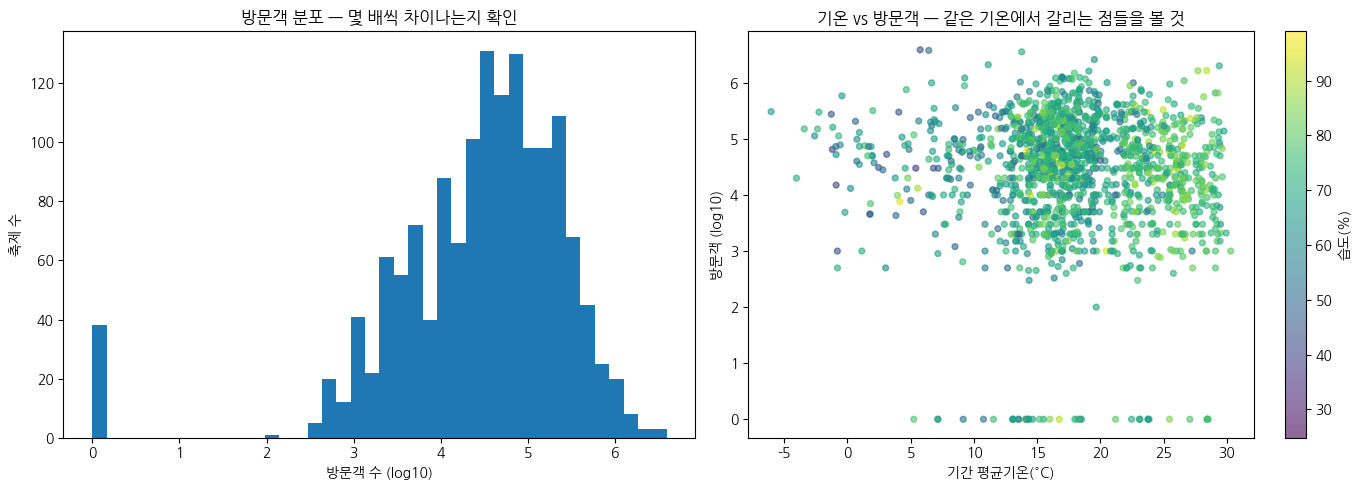

날씨 변수와 log방문객의 상관계수:
기온       -0.059
습도       -0.051
풍속       -0.026
log방문객    1.000


In [30]:
!pip install koreanize-matplotlib -q
import koreanize_matplotlib
import matplotlib.pyplot as plt

final["log방문객"] = np.log10(final["방문객"].clip(lower=1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(final["log방문객"], bins=40)
axes[0].set_xlabel("방문객 수 (log10)"); axes[0].set_ylabel("축제 수")
axes[0].set_title("방문객 분포 — 몇 배씩 차이나는지 확인")

sc = axes[1].scatter(final["기온"], final["log방문객"], c=final["습도"], alpha=0.6, s=18)
fig.colorbar(sc, ax=axes[1], label="습도(%)")
axes[1].set_xlabel("기간 평균기온(°C)"); axes[1].set_ylabel("방문객 (log10)")
axes[1].set_title("기온 vs 방문객 — 같은 기온에서 갈리는 점들을 볼 것")

plt.tight_layout(); plt.show()

print("날씨 변수와 log방문객의 상관계수:")
print(final[["기온", "습도", "풍속", "log방문객"]].corr()["log방문객"].round(3).to_string())

In [31]:
## EDA가 찾아낸 것
#방문객 분포에서 0~1명짜리 이상 덩어리 발견 → 미집계/형식 입력으로 판단, 제외.
#이 정제만으로 검증 R²이 0.48 → 0.79로 상승. 모델보다 데이터가 먼저였다.

In [32]:
n_bad = (final["방문객"] <= 10).sum()
print(f"방문객 10명 이하: {n_bad}행 → 미집계/형식 입력으로 판단해 제외")
final = final[final["방문객"] > 10].copy()
print(f"남은 데이터: {len(final)}행")

방문객 10명 이하: 38행 → 미집계/형식 입력으로 판단해 제외
남은 데이터: 1438행


In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

def apparent_temp(t, h, w):
    e = (h / 100) * 6.105 * np.exp(17.27 * t / (237.7 + t))
    return t + 0.33 * e - 0.70 * w - 4.0

final["체감기온"] = apparent_temp(final["기온"], final["습도"], final["풍속"])
final["키"] = final["광역"].fillna("") + "|" + final["축제명"].map(norm_name)

# 학습: 2023년 개최분 (과거이력 = 같은 축제의 2022년 실적)
h22 = final[final["연도"] == 2022].drop_duplicates("키").set_index("키")["log방문객"]
train = final[final["연도"] == 2023].copy()
train["과거이력"] = train["키"].map(h22)
train = train.dropna(subset=["과거이력"])

# 검증: 2024년 개최분 (과거이력 = 같은 축제의 2022~23 평균)
hist = final[final["연도"] <= 2023].groupby("키")["log방문객"].mean()
valid = final[final["연도"] == 2024].copy()
valid["과거이력"] = valid["키"].map(hist)
valid = valid.dropna(subset=["과거이력"])

def run(feats):
    m = LinearRegression().fit(train[feats], train["log방문객"])
    return r2_score(valid["log방문객"], m.predict(valid[feats]))

print(f"학습 {len(train)}행 / 검증 {len(valid)}행 (2년 이상 개최된 축제만)\n")
print(f"R²  과거이력만          : {run(['과거이력']):.3f}")
print(f"R²  + 기온·습도·풍속    : {run(['과거이력', '기온', '습도', '풍속']):.3f}")
print(f"R²  + 체감기온          : {run(['과거이력', '기온', '습도', '풍속', '체감기온']):.3f}")

학습 208행 / 검증 362행 (2년 이상 개최된 축제만)

R²  과거이력만          : 0.788
R²  + 기온·습도·풍속    : 0.780
R²  + 체감기온          : 0.780


In [34]:
p = final[["키", "연도", "log방문객", "체감기온"]].dropna()
m = p.merge(p, on="키", suffixes=("_전", "_후"))
m = m[m["연도_후"] == m["연도_전"] + 1]
m["방문객변화"] = m["log방문객_후"] - m["log방문객_전"]
m["체감기온변화"] = m["체감기온_후"] - m["체감기온_전"]
print(f"같은 축제의 연속 개최 쌍: {len(m)}건")
print(f"체감기온 변화 ↔ 방문객 변화 상관계수: {m['방문객변화'].corr(m['체감기온변화']):.3f}")

같은 축제의 연속 개최 쌍: 560건
체감기온 변화 ↔ 방문객 변화 상관계수: -0.039


In [35]:
## 결론과 한계
#- 과거 실적 기준선 모델: 2024년 검증 R² 0.79
#- 날씨·체감기온 추가 효과는 검출되지 않음 (연속 개최 560쌍 변화량 상관 -0.04)
#- 원인 진단: ① 광역 대표 관측소 근사(축제장과의 거리) ② 월단위 매칭이 절반 → 날씨 신호 희석
#- 후속 과제: 축제장 좌표 기반 최근접 관측소 + 일단위 매칭으로 재검증